# Function 7

<b> Description of the Sample Application:</b> You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance




## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Appended Week 2's input and output to the dataset.<br>2. Re-ran kernel comparison (RBF vs Matern) on the updated 32-point data set.<br>3. Lowered β from 1.2 to 0.8, continuing the shift toward exploitation.<br>4. Reused the consolidated bayesian_optimization_step() function unchanged.<br>7. Updated convergence and parallel-coordinates plots to include Week 2/3. |
| 13/08/2026 | Week 4 | 1. Appended Week-3 input and output data points.<br>2. **New**: restricted the acquisition search to a local neighbourhood around the current best point instead of the full unit cube.<br>3. **New**: Implemented Expected Improvement (EI) and compared it against UCB on that neighbourhood, since Weeks 2-3's global-UCB queries both underperformed the known best. |

## Progress log

| Week | Query point (x1–x6) | Output (y) | Method | Notes |
|---|---|---|---|---|
|  |  |  |  |  |
| 1 | 0.000000-0.000000-0.967840-0.233394-0.376268-0.804137 | 1.331930 | GP (RBF) + UCB (β=2.0), random-sample search | Exploration-heavy first query; landed on the domain edge for x1, x2 |
| 2 | 0.000000-0.000000-1.000000-0.198783-0.377305-0.792654 | 0.909142 | GP (Matern 5/2, CV-selected) + UCB (β = 1.2) | Result: Lower than predicted (mean ≈ 1.40), the GP overestimated. x3 pinned at the domain edge || 3 | 0.000000-0.424949-0.000000-0.083071-0.363094-0.823966 | **0.793646** | GP (Matern, re-confirmed) + UCB (β=0.8) | Third query in a row below the known best (1.365); x1, x3 pinned at 0 again - global UCB keeps favouring boundary points that don't pay off |
| 4 | - | - | GP (Matern) + *local-neighbourhood search*, EI vs UCB compared | Switching strategy: restrict candidates to a region around the current best, and use EI to check whether it recommends a different point than UCB |||

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.model_selection import KFold
from scipy.optimize import minimize
from plotting_utils import (
    plot_gp_1d, plot_acquisition_1d, plot_bo_iteration_1d,
    plot_convergence, plot_parallel_coordinates
)


# Load and Analyse the Data

In [10]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)


In [12]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.039632, 0.201121, 0.140302, 0.063997, 0.319477, 0.78773 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([1.3319298110135898]                                           , dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.      , 0.      , 1.      , 0.198783, 0.377305, 0.792654]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([0.9091420611100625]                                           , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.      , 0.424949, 0.      , 0.083071, 0.363094, 0.823966]   , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([0.7936458699948383]                                           , dtype=np.float64)   # from output.txt

In [14]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point
                              ])

In [16]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [18]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)

Input  Shape: (33, 6)
Inputs:
 [[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0

# Data Exploration

In [21]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  33.000000  33.000000  33.000000  33.000000  33.000000  33.000000   
mean    0.465612   0.378792   0.388744   0.476680   0.456845   0.513499   
std     0.323822   0.252237   0.328183   0.319375   0.301550   0.272616   
min     0.000000   0.000000   0.000000   0.063997   0.014944   0.051100   
25%     0.148647   0.195545   0.065931   0.198783   0.191531   0.343133   
50%     0.528497   0.377440   0.295542   0.420385   0.413631   0.619082   
75%     0.764919   0.528045   0.680013   0.807245   0.718440   0.730660   
max     0.942451   0.924694   1.000000   0.961017   0.998655   0.951014   

               Y  
count  33.000000  
mean    0.291603  
std     0.379541  
min     0.002701  
25%     0.018209  
50%     0.092645  
75%     0.516457  
max     1.364968  


In [23]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
Y      0
dtype: int64


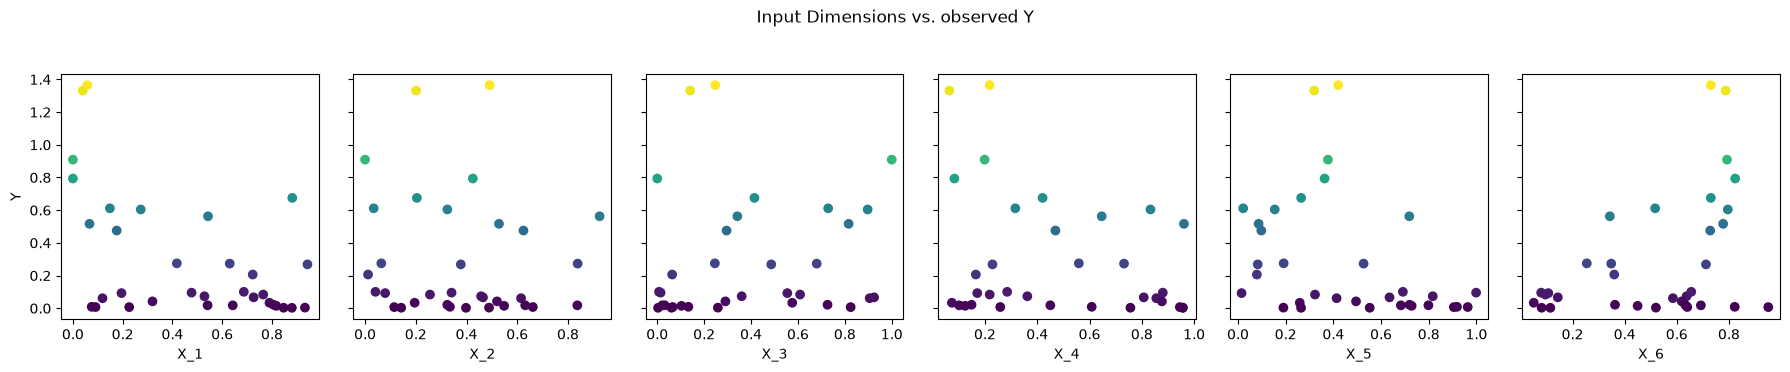

In [25]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6']):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

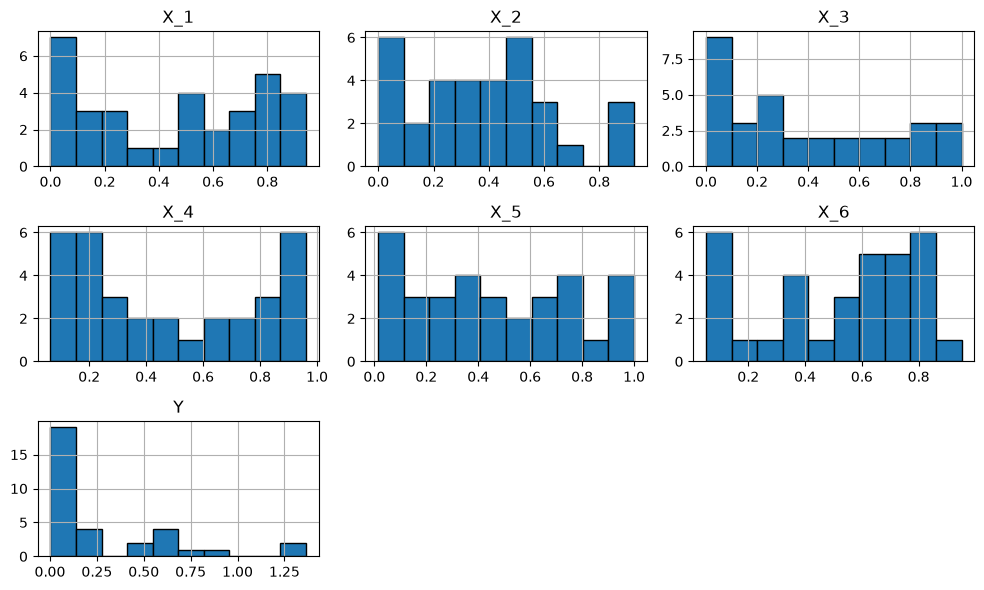

In [27]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [29]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.5064484111788711
 corr(X_2, Y) = -0.10571730679912092
 corr(X_3, Y) = 0.10491812942186489
 corr(X_4, Y) = -0.28045136317586405
 corr(X_5, Y) = -0.36081728578105293
 corr(X_6, Y) = 0.426829473667204


<Axes: >

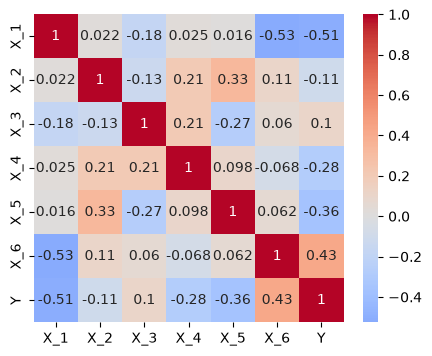

In [31]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

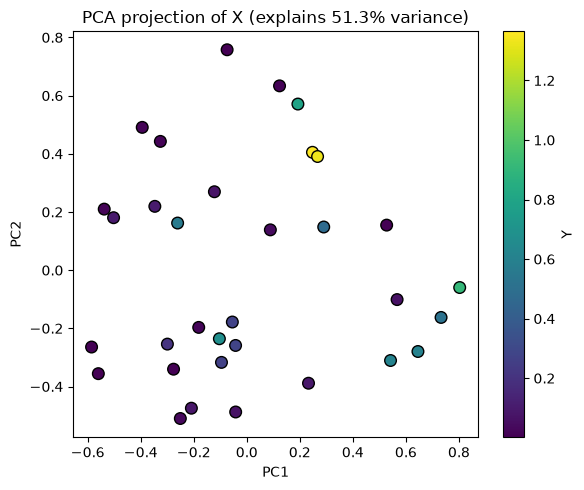

In [33]:
# Identify clustering of high-y points using PCA projection to 2D
pca  = PCA(n_components = 2)
X2   = pca.fit_transform(X)
plt.figure(figsize = (6, 5))
sc   = plt.scatter(X2[:, 0], X2[:, 1], c = Y, cmap = "viridis", s = 70, edgecolor = "k")
plt.colorbar(sc, label = "Y")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum() * 100:.1f}% variance)")
plt.tight_layout()

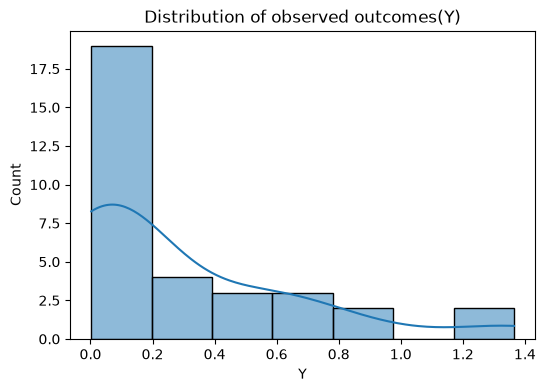

In [35]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [38]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(6), length_scale_bounds = (1e-2, 1e1)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [41]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.347**2 * RBF(length_scale=[0.829, 0.655, 1.46, 10, 0.265, 0.0705]) + WhiteKernel(noise_level=1e-06)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [45]:
# Setting a higher beta(= 2.0) for Week -1
beta         = 2.0

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (20000, 6))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.10695852 0.22049351 0.27262831 0.68005421 0.38642259 0.75467713]
UCB Score: 1.657582e+00


# Week 2: Kernel Comparison
RBF assumes an infinitely 
smooth surfac.; Matern is typically a better match for ML-performance landscape2). Both kernels are compared here with 5-fold cross-validated predicti e
log-likelihood t (31-pont) data et, and the better one selected.ook.

In [48]:
DIM   = 6
def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    return GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer = 8, random_state = 0)

kernel_options = {  
    "RBF":            RBF(length_scale = np.ones(DIM), length_scale_bounds = (1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale = np.ones(DIM), length_scale_bounds = (1e-2, 1e1), nu = 2.5),
}

kf = KFold(n_splits = 5, shuffle = True, random_state = 0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls   = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std = True)
        sigma     = np.maximum(sigma, 1e-6)
        ll        = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:16s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key = cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 2: {best_kernel_name}")

  RBF             : CV log-likelihood = -4.055
  Matern(nu = 2.5): CV log-likelihood = -2.208

Selected kernel for Week 2: Matern(nu = 2.5)


# Week2: Bayesian Optimisation Function

In [51]:
def bayesian_optimization_step(X, Y, kernel, beta = 2.0, n_candidates = 20000, n_restarts = 40, use_optimizer = True, seed = 7):
    
    rng    = np.random.default_rng(seed)
    n_dims = X.shape[1]
    bounds = [(0.0, 1.0)] * n_dims

    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    gp = GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer=8, random_state = 0)
    gp.fit(X, Y)

    def ucb(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std = True)
        return mu + beta * sigma

    # Evaluate a random candidate set
    candidates       = rng.uniform(0, 1, size = (n_candidates, n_dims))
    candidate_ucb    = ucb(candidates)
    best_idx         = np.argmax(candidate_ucb)
    next_x, next_ucb = candidates[best_idx], candidate_ucb[best_idx]

    if use_optimizer:
        starts   = rng.uniform(0, 1, size = (n_restarts, n_dims))
        best_val = -next_ucb
        for x0 in starts:
            res  = minimize(lambda x: -ucb(x)[0], x0, method = "L-BFGS-B", bounds = bounds)
            if res.fun < best_val:
                best_val, next_x = res.fun, res.x
        next_x   = np.clip(next_x, 0.0, 1.0)
        next_ucb = ucb(next_x)[0]

    return {
        "gp": gp, "next_x": next_x, "next_ucb": next_ucb,
        "candidates": candidates, "candidate_ucb": candidate_ucb,
    }


In [53]:
# Week 2: Calling the Bayesian Optimisation Function
beta   = 1.2       # In week 2, beta is lowered from 2.0 to 1.2

result = bayesian_optimization_step(X, Y, chosen_kernel, beta = beta, n_candidates = 20000, n_restarts = 40, seed = 7)
gp = result["gp"]
next_x = result["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std = True)

print(f"Kernel used   : {best_kernel_name}")
print(f"β             : {beta}")
print(f"Next point    : {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   UCB: {result['next_ucb']:.4f}")


Kernel used   : Matern(nu = 2.5)
β             : 1.2
Next point    : [0.       0.240911 0.       0.       0.363472 0.751383]
Predicted mean: 1.4935   std: 0.1099   UCB: 1.6254


# Week 3: Calling the Bayesian Optimisation Function

In [56]:
# Week 3: beta lowered from 1.2 to 0.8 
beta   = 0.8

result = bayesian_optimization_step(X, Y, chosen_kernel, beta=beta, n_candidates=20000,
                                     n_restarts=40, seed=7)
gp     = result["gp"]
next_x = result["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)

print(f"Kernel used   : {best_kernel_name}")
print(f"beta          : {beta}")
print(f"Next point    : {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   UCB: {result['next_ucb']:.4f}")

Kernel used   : Matern(nu = 2.5)
beta          : 0.8
Next point    : [0.       0.269098 0.032462 0.016622 0.363327 0.752728]
Predicted mean: 1.5011   std: 0.1022   UCB: 1.5829


# Perform Visualisation

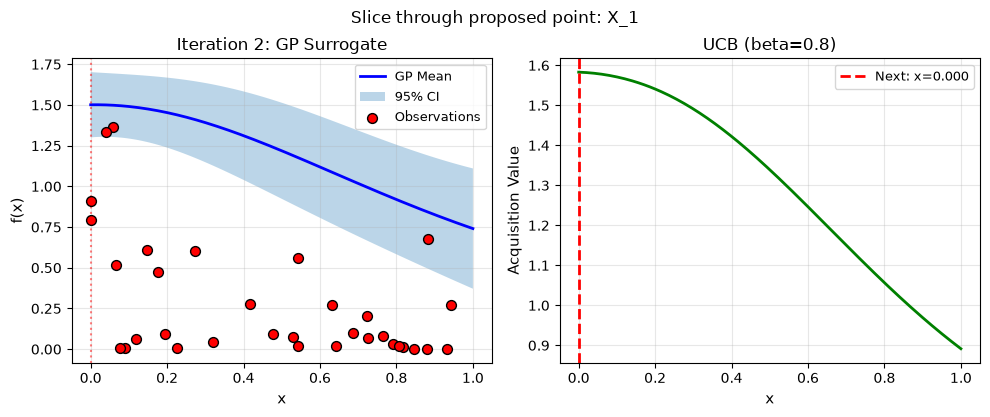

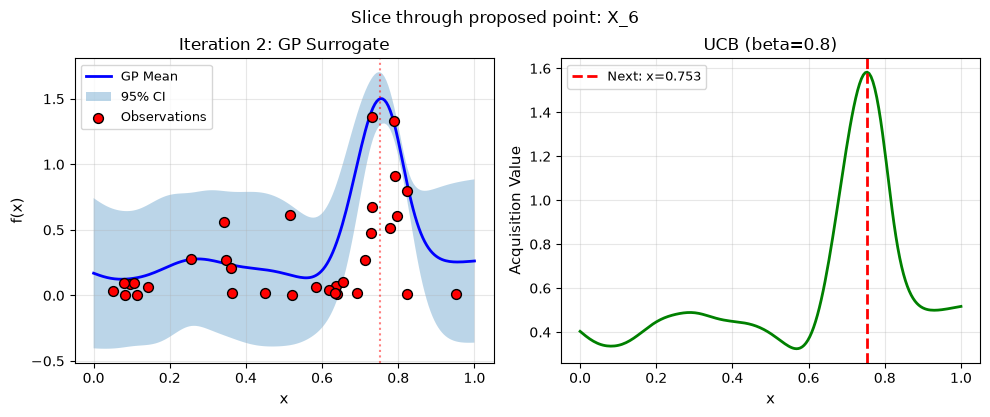

In [58]:
corrs    = [abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(DIM)]
top_dims = np.argsort(corrs)[-2:][::-1]
grid     = np.linspace(0, 1, 200).reshape(-1, 1)

for d in top_dims:
    Xg            = np.tile(next_x, (len(grid), 1))
    Xg[:, d]      = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std = True)
    ucb_g         = mu_g + beta * sigma_g

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train = Y,
        X_test=grid, mu = mu_g, sigma = sigma_g,
        acquisition_values = ucb_g, X_next  =next_x[d],
        iteration = 2, acq_name = f"UCB (beta={beta})"
    )
    fig.suptitle(f"Slice through proposed point: X_{d+1}", y = 1.03)
    plt.show()


In [66]:
# Week 4: Kernel Comparison with new dataset
kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        ll = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:16s}: CV log-likelihood = {cv_scores[name]:+.3f}")
    
best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 4: {best_kernel_name}")

  RBF             : CV log-likelihood = -4.055
  Matern(nu = 2.5): CV log-likelihood = -2.208

Selected kernel for Week 4: Matern(nu = 2.5)


# WEEK 4: Local-neighbourhood Bayesian optimisation step, with EI vs UCB
Two changes from the Weeks 2-3 bayesian_optimization_step():

1. **Local search radius      :** Candidates (and optimiser restarts) are drawn from a box of *± radius* around the current best point, instead of the full 6D unit cube. This directly targets the pattern from Weeks 1-3, where a *global* search kept selecting boundary points that under-delivered.
2. **Expected Improvement (EI):** EI is computed alongside UCB on the same neighbourhood so the two acquisition functions can be compared directly rather than trusting UCB by default.

In [70]:
def expected_improvement(mu, sigma, y_best, xi = 0.01):
    '''Expected Improvement: how much improvement over y_best is expected.'''
    sigma        = np.maximum(sigma, 1e-9)
    improvement  = mu - y_best - xi
    Z            = improvement / sigma
    ei           = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei           = np.where(sigma < 1e-8, 0.0, ei)
    return ei


def bayesian_optimization_step_local(X, Y, kernel, beta = 0.8, xi = 0.01,
                                      radius = 0.15, n_candidates = 20000, n_restarts = 40,
                                      seed=7):
    rng          = np.random.default_rng(seed)
    n_dims       = X.shape[1]

    k            = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    gp           = GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer = 8, random_state = 0)
    gp.fit(X, Y)

    y_best       = Y.max()
    x_best       = X[np.argmax(Y)]

    # Local search box: [x_best - radius, x_best + radius], clipped to [0, 1]
    local_low    = np.clip(x_best - radius, 0.0, 1.0)
    local_high   = np.clip(x_best + radius, 0.0, 1.0)
    local_bounds = list(zip(local_low, local_high))

    def ucb_fn(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
        return mu + beta * sigma

    def ei_fn(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std = True)
        return expected_improvement(mu, sigma, y_best, xi = xi)

    # Local random candidate cloud
    candidates = rng.uniform(local_low, local_high, size = (n_candidates, n_dims))

    results    = {}
    for name, acq in [("ucb", ucb_fn), ("ei", ei_fn)]:
        acq_vals = acq(candidates)
        best_idx = np.argmax(acq_vals)
        next_x, next_val = candidates[best_idx], acq_vals[best_idx]

        starts   = rng.uniform(local_low, local_high, size=(n_restarts, n_dims))
        best_val = -next_val
        for x0 in starts:
            res  = minimize(lambda x: -acq(x)[0], x0, method = "L-BFGS-B", bounds = local_bounds)
            if res.fun < best_val:
                best_val, next_x = res.fun, res.x
        next_x   = np.clip(next_x, local_low, local_high)
        next_val = acq(next_x)[0]
        results[name] = {"next_x": next_x, "value": next_val}

    return {
        "gp": gp, "x_best": x_best, "y_best": y_best,
        "local_bounds": local_bounds, "ucb": results["ucb"], "ei": results["ei"],
    }


# Week 4: Calling the local-neighbourhood function

In [77]:
RADIUS = 0.15
beta   = 0.8

week4  = bayesian_optimization_step_local(X, Y, chosen_kernel, beta=beta, xi=0.01,
                                          radius=RADIUS, n_candidates=20000,
                                          n_restarts=40, seed=7)

gp    = week4["gp"]
print(f"Kernel used     : {best_kernel_name}")
print(f"Current best    : Y = {week4['y_best']:.6f} at x = {np.round(week4['x_best'], 6)}")
print(f"Local box       : radius = {RADIUS} around x_best (clipped to [0,1])\n")

for name in ["ucb", "ei"]:
    r = week4[name]
    mu_r, sigma_r = gp.predict(r["next_x"].reshape(1, -1), return_std=True)
    print(f"[{name.upper()}] next point: {np.round(r['next_x'], 6)}")
    print(f"        predicted mean={mu_r[0]:.4f}  std={sigma_r[0]:.4f}  {name.upper()} value={r['value']:.4f}\n")

Kernel used     : Matern(nu = 2.5)
Current best    : Y = 1.364968 at x = [0.057896 0.491672 0.247422 0.218118 0.420428 0.73097 ]
Local box       : radius = 0.15 around x_best (clipped to [0,1])

[UCB] next point: [0.       0.341672 0.097422 0.068118 0.362672 0.752898]
        predicted mean=1.5026  std=0.0925  UCB value=1.5766

[EI] next point: [0.007106 0.341672 0.097422 0.068118 0.366155 0.753175]
        predicted mean=1.5031  std=0.0911  EI value=0.1315



# Comparing UCB vs EI

In [80]:
ucb_x, ei_x = week4["ucb"]["next_x"], week4["ei"]["next_x"]
diff        = np.linalg.norm(ucb_x - ei_x)
print(f"Euclidean distance between UCB's and EI's proposed points: {diff:.4f}")


next_x     = week4["ei"]["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std = True)

print(f"\nWeek 4 chosen point (EI): {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}")

Euclidean distance between UCB's and EI's proposed points: 0.0079

Week 4 chosen point (EI): [0.007106 0.341672 0.097422 0.068118 0.366155 0.753175]
Predicted mean: 1.5031   std: 0.0911


# Perform Visualisation

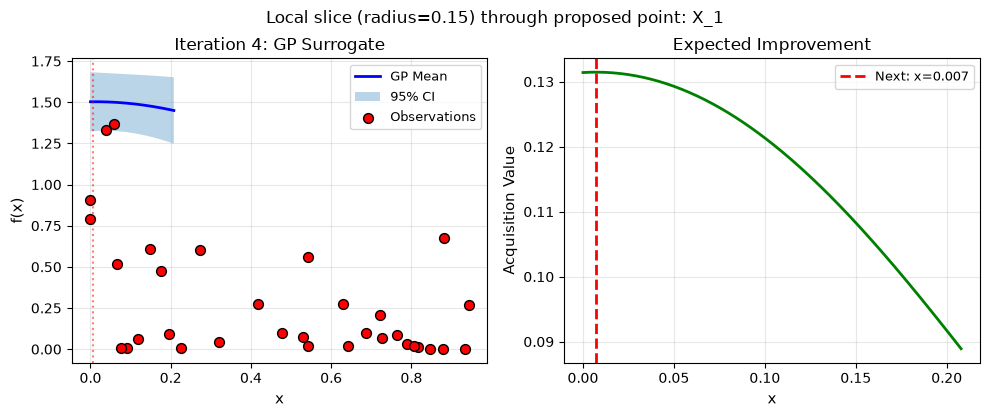

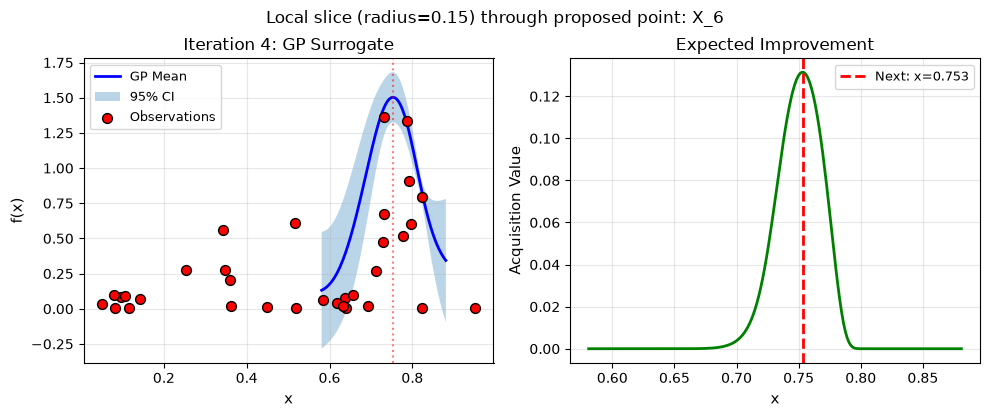

In [83]:
corrs = [abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(DIM)]
top_dims = np.argsort(corrs)[-2:][::-1]

for d in top_dims:
    lo, hi = week4["local_bounds"][d]
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, week4["y_best"], xi=0.01)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=4, acq_name="Expected Improvement"
    )
    fig.suptitle(f"Local slice (radius={RADIUS}) through proposed point: X_{d+1}", y=1.03)
    plt.show()

# Convergence and Top Solution

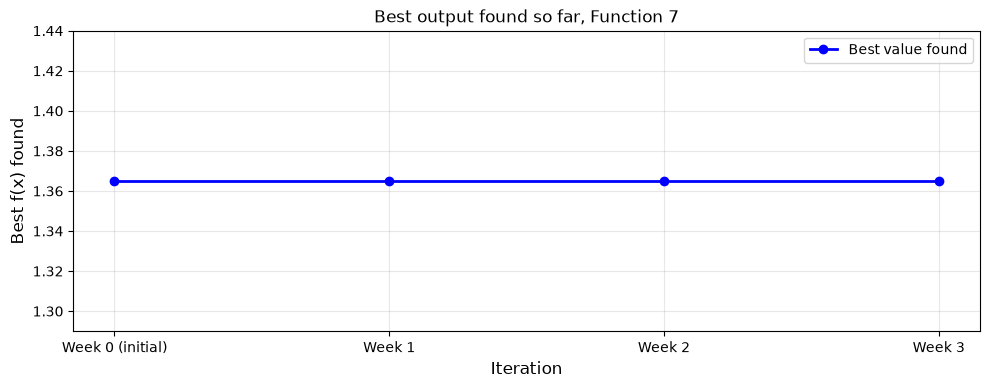

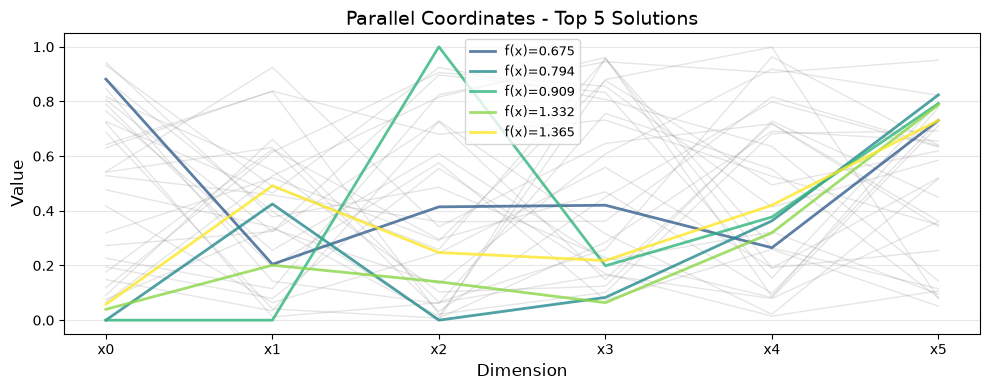

In [85]:
# Best-so-far after each stage of data collection
best_after_initial = Y[:-3].max()
best_after_week1   = Y[:-2].max()
best_after_week2   = Y[:-1].max()
best_after_week3   = Y.max()
best_values = [best_after_initial, best_after_week1, best_after_week2, best_after_week3]

plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), ["Week 0 (initial)", "Week 1", "Week 2", "Week 3"])
plt.title("Best output found so far, Function 7")
plt.show()

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()


# Portal Submission 

In [95]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_x)
print("Points to be submitted(Week 1):"  ,'0.039632-0.201121-0.140302-0.063997-0.319477-0.787730')
print("Points to be submitted(Week 2):"  ,'0.000000-0.000000-1.000000-0.198783-0.377305-0.792654')
print("Points to be submitted(Week 3):"  , "0.000000-0.424949-0.000000-0.083071-0.363094-0.823966")
print(f"Points to submit      (Week 4): {submission_str}")

Points to be submitted(Week 1): 0.039632-0.201121-0.140302-0.063997-0.319477-0.787730
Points to be submitted(Week 2): 0.000000-0.000000-1.000000-0.198783-0.377305-0.792654
Points to be submitted(Week 3): 0.000000-0.424949-0.000000-0.083071-0.363094-0.823966
Points to submit      (Week 4): 0.007106-0.341672-0.097422-0.068118-0.366155-0.753175
